# RQ2 Code Generation Analysis

**Purpose**: Analyze code generation results from RQ2 experiments comparing Dual-Agent vs Multi-Agent approaches.

**Datasets**: 16 code generation experiments (8 pods × 2 experiments per pod)
- **Dual-Agent (DA)**: 2-agent approach
- **Multi-Agent (MA)**: 4-agent approach  

**Research Questions**:
- **RQ2.1**: How do dual-agent and multi-agent approaches compare in code generation quality (Pass@1)?
- **RQ2.2**: What is the impact of prompting strategy (zero-shot vs few-shot)?
- **RQ2.3**: How do model size (4B vs 30B) and reasoning capabilities (Instruct vs Thinking) affect performance?
- **RQ2.4**: What are the energy efficiency tradeoffs?

**Metrics**: Pass@1 (percentage of samples that pass all test cases)

**Date**: November 17, 2025

## 1. Setup & Data Loading

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / 'results'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'analysis' / 'rq2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Project Root: {PROJECT_ROOT}")
print(f"📊 Results Directory: {RESULTS_DIR}")
print(f"💾 Output Directory: {OUTPUT_DIR}")

📂 Project Root: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green
📊 Results Directory: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results
💾 Output Directory: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis/rq2


## 2. Load Code Generation Results

In [77]:
# Define pod configurations
pod_configs = {
    'pod1': {'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Zero-shot'},
    'pod2': {'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    'pod3': {'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Few-shot'},
    'pod4': {'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
    'pod5': {'model_size': '30B', 'model_type': 'Instruct', 'prompting': 'Zero-shot'},
    'pod6': {'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Zero-shot'},
    'pod7': {'model_size': '30B', 'model_type': 'Instruct', 'prompting': 'Few-shot'},
    'pod8': {'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot'},
}

# Load all code generation results
all_results = []

for pod_name, config in pod_configs.items():
    pod_dir = RESULTS_DIR / f'runpod_rq2_{pod_name}'
    
    # Handle nested results directories
    if (pod_dir / 'results').exists():
        pod_dir = pod_dir / 'results'
    
    # Find DA and MA code generation evaluation files
    da_files = list(pod_dir.glob('DA-code-*_evaluation.json'))
    ma_files = list(pod_dir.glob('MA-code-*_evaluation.json'))
    
    for file in da_files + ma_files:
        agent_type = 'Dual-Agent' if 'DA-' in file.name else 'Multi-Agent'
        
        # Load evaluation JSON
        with open(file, 'r') as f:
            eval_data = json.load(f)
        
        # Extract Pass@1 score from metrics (nested structure)
        if 'metrics' in eval_data:
            metrics = eval_data['metrics']
            pass_at_1 = metrics.get('pass@1', metrics.get('pass_at_1', 0))
            total_samples = metrics.get('total_samples', metrics.get('n', 0))
            passed_samples = metrics.get('passed_samples', metrics.get('c', 0))
        else:
            # Fallback to top-level (older format)
            pass_at_1 = eval_data.get('pass@1', eval_data.get('pass_at_1', 0))
            total_samples = eval_data.get('total_samples', eval_data.get('n', 0))
            passed_samples = eval_data.get('passed', eval_data.get('c', 0))
        
        result = {
            'pod': pod_name,
            'agent_type': agent_type,
            'model_size': config['model_size'],
            'model_type': config['model_type'],
            'prompting': config['prompting'],
            'pass_at_1': pass_at_1,
            'pass_at_1_pct': pass_at_1 * 100,
            'total_samples': total_samples,
            'passed_samples': passed_samples,
            'file': file.name
        }
        all_results.append(result)

# Create DataFrame
df_code = pd.DataFrame(all_results)

print(f"\n📊 Loaded {len(df_code)} code generation experiments")
print(f"\nColumns: {list(df_code.columns)}")
df_code.head(10)


📊 Loaded 15 code generation experiments

Columns: ['pod', 'agent_type', 'model_size', 'model_type', 'prompting', 'pass_at_1', 'pass_at_1_pct', 'total_samples', 'passed_samples', 'file']


,pod,agent_type,model_size,model_type,prompting,pass_at_1,pass_at_1_pct,total_samples,passed_samples,file
0,pod1,Multi-Agent,4B,Instruct,Zero-shot,1.000000,100.000000,164,164,MA-code-zero_shot_Qwen-Qwen3-4B-Instruct-2507_...
1,pod2,Dual-Agent,4B,Thinking,Zero-shot,0.640244,64.024390,164,105,DA-code-zero_shot_Qwen-Qwen3-4B-Thinking-2507_...
2,pod2,Multi-Agent,4B,Thinking,Zero-shot,0.987805,98.780488,164,162,MA-code-zero_shot_Qwen-Qwen3-4B-Thinking-2507_...
3,pod3,Dual-Agent,4B,Instruct,Few-shot,1.000000,100.000000,164,164,DA-code-few_shot_Qwen-Qwen3-4B-Instruct-2507_2...
4,pod3,Multi-Agent,4B,Instruct,Few-shot,1.000000,100.000000,164,164,MA-code-few_shot_Qwen-Qwen3-4B-Instruct-2507_2...
5,pod4,Dual-Agent,4B,Thinking,Few-shot,0.890244,89.024390,164,146,DA-code-few_shot_Qwen-Qwen3-4B-Thinking-2507_2...
6,pod4,Multi-Agent,4B,Thinking,Few-shot,0.945122,94.512195,164,155,MA-code-few_shot_Qwen-Qwen3-4B-Thinking-2507_2...
7,pod5,Dual-Agent,30B,Instruct,Zero-shot,0.975610,97.560976,164,160,DA-code-zero_shot_Qwen-Qwen3-30B-A3B-Instruct-...
8,pod5,Multi-Agent,30B,Instruct,Zero-shot,0.993902,99.390244,164,163,MA-code-zero_shot_Qwen-Qwen3-30B-A3B-Instruct-...
9,pod6,Dual-Agent,30B,Thinking,Zero-shot,0.465753,46.575342,146,68,DA-code-zero_shot_Qwen-Qwen3-30B-A3B-Thinking-...


## 3. Load Energy Data

In [78]:
# Load energy data from emissions.csv files
# IMPORTANT: Aggregate by experiment type, not by entire pod!
energy_data = []

def extract_experiment_type(project_name):
    """Extract experiment type from project_name in emissions.csv"""
    if 'DA-vuln' in project_name:
        return 'DA-vuln'
    elif 'DA-code' in project_name:
        return 'DA-code'
    elif 'MA-vuln' in project_name:
        return 'MA-vuln'
    elif 'MA-code' in project_name:
        return 'MA-code'
    else:
        return 'Unknown'

for pod_name, config in pod_configs.items():
    pod_dir = RESULTS_DIR / f'runpod_rq2_{pod_name}'
    
    # Handle nested results directories
    emissions_file = pod_dir / 'emissions.csv'
    if not emissions_file.exists():
        emissions_file = pod_dir / 'results' / 'emissions.csv'
    
    if emissions_file.exists():
        df_emissions = pd.read_csv(emissions_file)
        
        # Extract experiment type from project_name
        df_emissions['experiment_type'] = df_emissions['project_name'].apply(extract_experiment_type)
        
        # Group by experiment type and sum energy/emissions
        energy_by_exp = df_emissions.groupby('experiment_type').agg({
            'energy_consumed': 'sum',
            'emissions': 'sum'
        }).reset_index()
        
        # Add pod info and append
        for _, row in energy_by_exp.iterrows():
            energy_data.append({
                'pod': pod_name,
                'experiment_type': row['experiment_type'],
                'energy_kwh': row['energy_consumed'],
                'emissions_kg': row['emissions']
            })

df_energy = pd.DataFrame(energy_data)

# Filter for code generation experiments only (DA-code and MA-code)
df_energy_code = df_energy[df_energy['experiment_type'].isin(['DA-code', 'MA-code'])].copy()

# Map experiment_type to agent_type for merging
df_energy_code['agent_type'] = df_energy_code['experiment_type'].map({
    'DA-code': 'Dual-Agent',
    'MA-code': 'Multi-Agent'
})

# Merge energy data with code generation results
df_code = df_code.merge(
    df_energy_code[['pod', 'agent_type', 'energy_kwh', 'emissions_kg']], 
    on=['pod', 'agent_type'], 
    how='left'
)

# Rename for backward compatibility with rest of notebook
df_code['total_energy_kwh'] = df_code['energy_kwh']
df_code['total_emissions_kg'] = df_code['emissions_kg']

# Calculate energy per sample
df_code['energy_per_sample'] = df_code['total_energy_kwh'] / df_code['total_samples']

print("\n✅ Energy data loaded and merged by experiment type (DA-code vs MA-code)!")
print(f"\nEnergy breakdown by experiment type:")
print(df_energy_code.groupby('experiment_type')[['energy_kwh', 'emissions_kg']].sum())
df_code.head()


✅ Energy data loaded and merged by experiment type (DA-code vs MA-code)!

Energy breakdown by experiment type:
                 energy_kwh  emissions_kg
experiment_type                          
DA-code            2.587241      0.439942
MA-code            4.799255      0.816080


,pod,agent_type,model_size,model_type,prompting,pass_at_1,pass_at_1_pct,total_samples,passed_samples,file,energy_kwh,emissions_kg,total_energy_kwh,total_emissions_kg,energy_per_sample
0,pod1,Multi-Agent,4B,Instruct,Zero-shot,1.000000,100.000000,164,164,MA-code-zero_shot_Qwen-Qwen3-4B-Instruct-2507_...,0.230137,0.039133,0.230137,0.039133,0.001403
1,pod2,Dual-Agent,4B,Thinking,Zero-shot,0.640244,64.024390,164,105,DA-code-zero_shot_Qwen-Qwen3-4B-Thinking-2507_...,0.710241,0.120772,0.710241,0.120772,0.004331
2,pod2,Multi-Agent,4B,Thinking,Zero-shot,0.987805,98.780488,164,162,MA-code-zero_shot_Qwen-Qwen3-4B-Thinking-2507_...,1.173458,0.199538,1.173458,0.199538,0.007155
3,pod3,Dual-Agent,4B,Instruct,Few-shot,1.000000,100.000000,164,164,DA-code-few_shot_Qwen-Qwen3-4B-Instruct-2507_2...,0.107970,0.018360,0.107970,0.018360,0.000658
4,pod3,Multi-Agent,4B,Instruct,Few-shot,1.000000,100.000000,164,164,MA-code-few_shot_Qwen-Qwen3-4B-Instruct-2507_2...,0.212963,0.036213,0.212963,0.036213,0.001299


## 4. RQ2.1: Dual-Agent vs Multi-Agent Comparison

📊 Dual-Agent vs Multi-Agent Pass@1 Performance:

              mean    std    min    max
agent_type                             
Dual-Agent   79.56  20.01  46.58  100.0
Multi-Agent  97.26   3.60  90.24  100.0


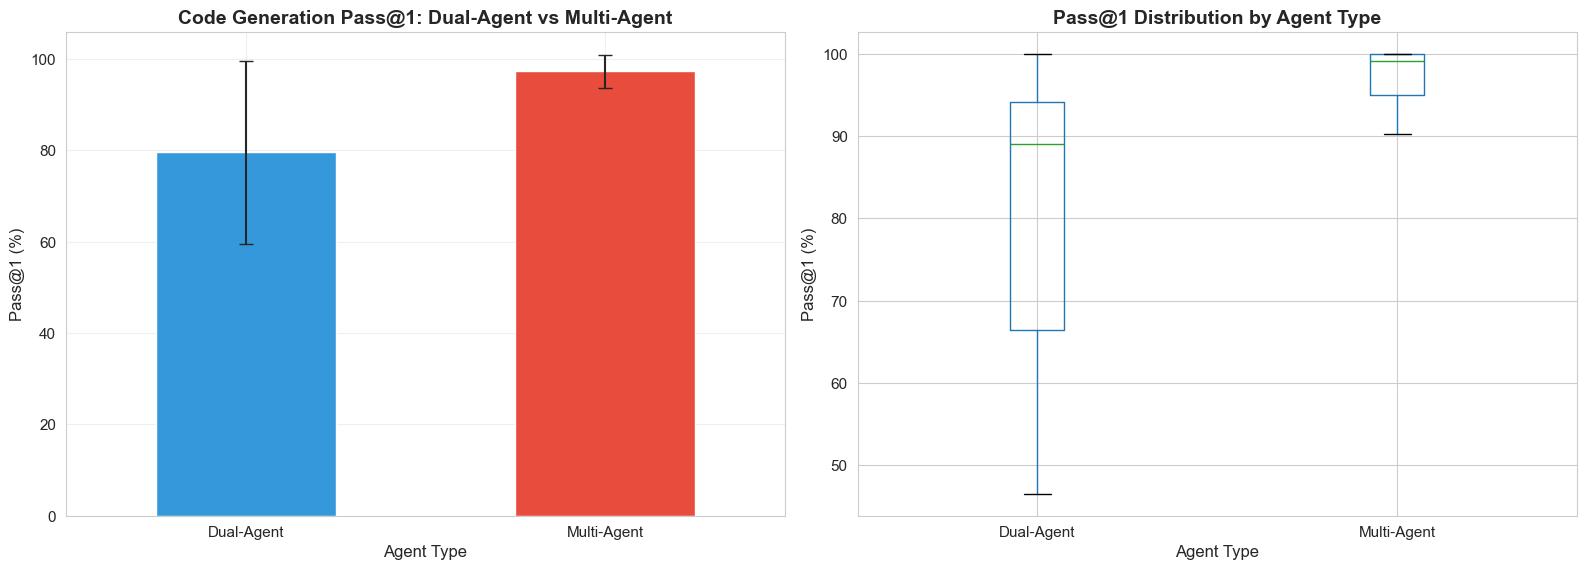


📊 T-test (DA vs MA Pass@1): t=-2.469, p=0.028
   ✅ Statistically significant difference!


In [79]:
# Compare DA vs MA performance
agent_comparison = df_code.groupby('agent_type')['pass_at_1_pct'].agg(['mean', 'std', 'min', 'max'])

print("📊 Dual-Agent vs Multi-Agent Pass@1 Performance:\n")
print(agent_comparison.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
agent_comparison['mean'].plot(kind='bar', ax=axes[0], rot=0, color=['#3498DB', '#E74C3C'], 
                               yerr=agent_comparison['std'], capsize=5)
axes[0].set_title('Code Generation Pass@1: Dual-Agent vs Multi-Agent', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Agent Type', fontsize=12)
axes[0].set_ylabel('Pass@1 (%)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Box plot
df_code.boxplot(column='pass_at_1_pct', by='agent_type', ax=axes[1])
axes[1].set_title('Pass@1 Distribution by Agent Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Agent Type', fontsize=12)
axes[1].set_ylabel('Pass@1 (%)', fontsize=12)
plt.suptitle('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_code_da_vs_ma_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical test
from scipy import stats
da_pass = df_code[df_code['agent_type'] == 'Dual-Agent']['pass_at_1_pct']
ma_pass = df_code[df_code['agent_type'] == 'Multi-Agent']['pass_at_1_pct']
t_stat, p_value = stats.ttest_ind(da_pass, ma_pass)
print(f"\n📊 T-test (DA vs MA Pass@1): t={t_stat:.3f}, p={p_value:.3f}")
if p_value < 0.05:
    print("   ✅ Statistically significant difference!")
else:
    print("   ⚠️  No statistically significant difference")

## 5. RQ2.2: Prompting Strategy Analysis

📊 Zero-shot vs Few-shot Pass@1 Performance:

            mean    std    min    max
prompting                            
Few-shot   91.69  10.31  68.90  100.0
Zero-shot  85.92  21.57  46.58  100.0


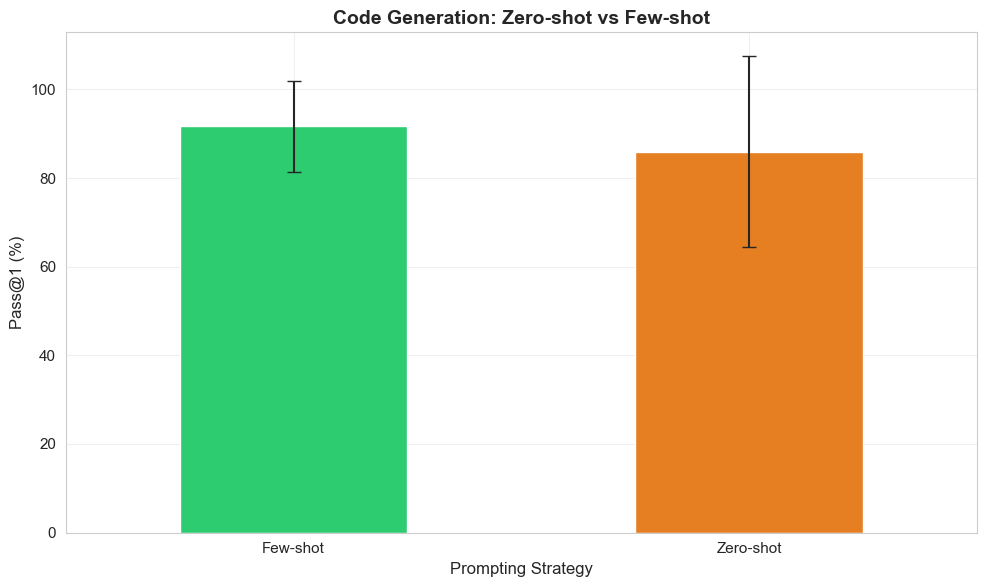

In [80]:
# Compare Zero-shot vs Few-shot
prompting_comparison = df_code.groupby('prompting')['pass_at_1_pct'].agg(['mean', 'std', 'min', 'max'])

print("📊 Zero-shot vs Few-shot Pass@1 Performance:\n")
print(prompting_comparison.round(2))

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
prompting_comparison['mean'].plot(kind='bar', ax=ax, rot=0, color=['#2ECC71', '#E67E22'],
                                   yerr=prompting_comparison['std'], capsize=5)
ax.set_title('Code Generation: Zero-shot vs Few-shot', fontsize=14, fontweight='bold')
ax.set_xlabel('Prompting Strategy', fontsize=12)
ax.set_ylabel('Pass@1 (%)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_code_prompting_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. RQ2.3: Model Configuration Analysis

📊 4B vs 30B Model Performance:

             mean    std
model_size              
30B         86.08  18.82
4B          92.33  13.13

📊 Instruct vs Thinking Performance:

             mean    std
model_type              
Instruct    98.26   3.38
Thinking    80.90  18.77


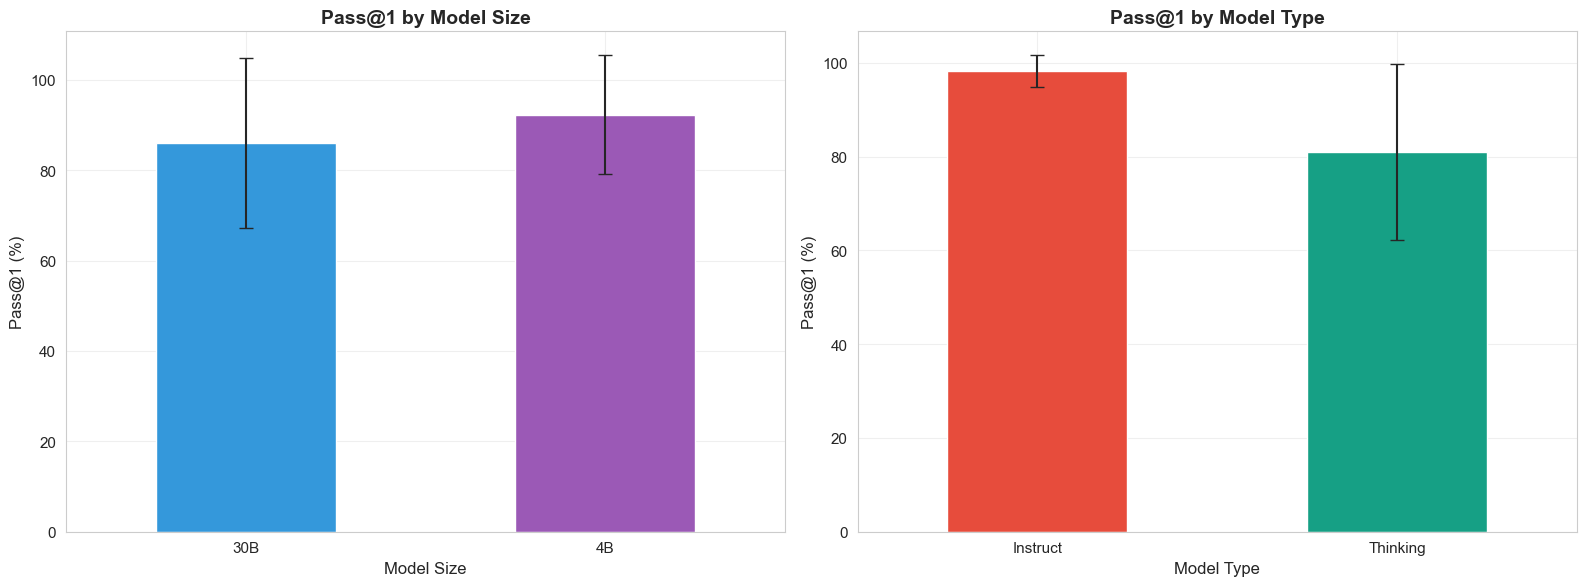

In [81]:
# Model size comparison
size_comparison = df_code.groupby('model_size')['pass_at_1_pct'].agg(['mean', 'std'])

print("📊 4B vs 30B Model Performance:\n")
print(size_comparison.round(2))

# Model type comparison
type_comparison = df_code.groupby('model_type')['pass_at_1_pct'].agg(['mean', 'std'])

print("\n📊 Instruct vs Thinking Performance:\n")
print(type_comparison.round(2))

# Combined visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

size_comparison['mean'].plot(kind='bar', ax=axes[0], rot=0, color=['#3498DB', '#9B59B6'],
                              yerr=size_comparison['std'], capsize=5)
axes[0].set_title('Pass@1 by Model Size', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Model Size', fontsize=12)
axes[0].set_ylabel('Pass@1 (%)', fontsize=12)
axes[0].grid(True, alpha=0.3)

type_comparison['mean'].plot(kind='bar', ax=axes[1], rot=0, color=['#E74C3C', '#16A085'],
                              yerr=type_comparison['std'], capsize=5)
axes[1].set_title('Pass@1 by Model Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Model Type', fontsize=12)
axes[1].set_ylabel('Pass@1 (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_code_model_configuration.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. RQ2.4: Energy Efficiency Analysis

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


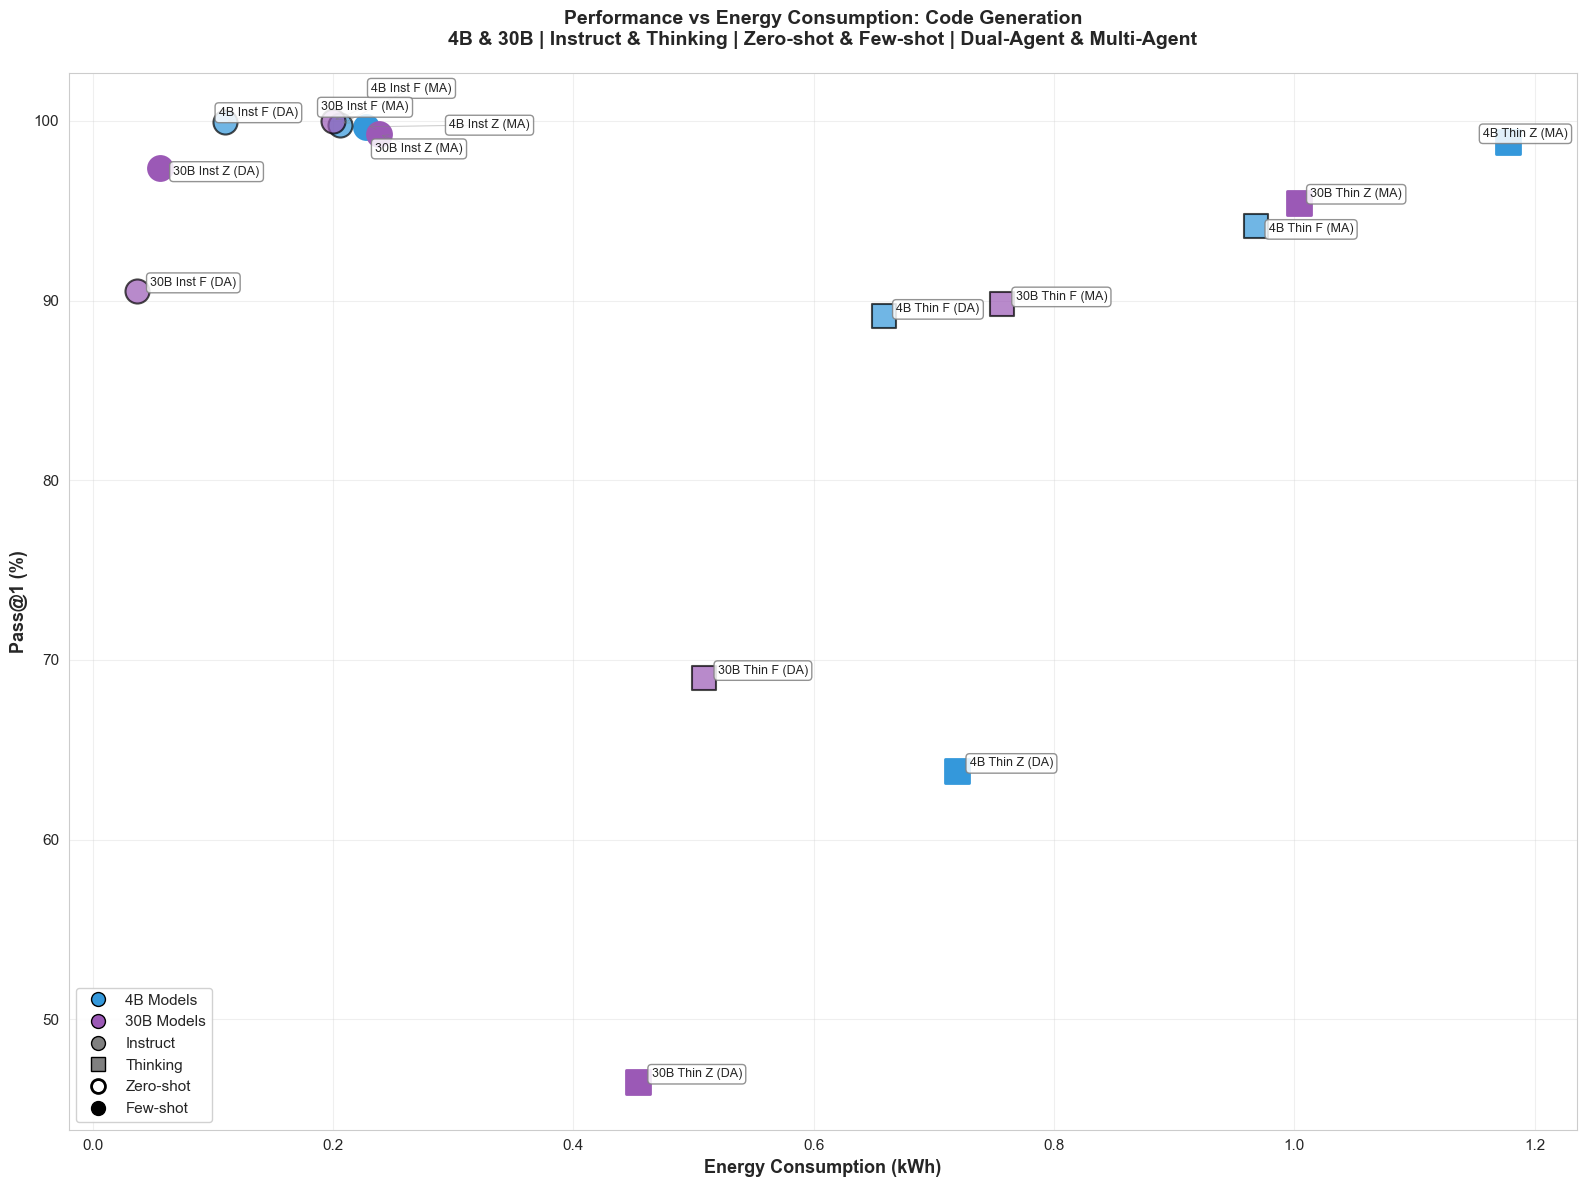


📊 Top 5 Most Energy-Efficient Configurations (Pass@1 per kWh):
 pod  agent_type model_size model_type prompting  pass_at_1_pct  energy_kwh  efficiency_pass1_per_kwh
pod7  Dual-Agent        30B   Instruct  Few-shot      90.853659    0.027695               3280.538987
pod5  Dual-Agent        30B   Instruct Zero-shot      97.560976    0.049013               1990.493378
pod3  Dual-Agent         4B   Instruct  Few-shot     100.000000    0.107970                926.181523
pod7 Multi-Agent        30B   Instruct  Few-shot     100.000000    0.193050                518.000221
pod3 Multi-Agent         4B   Instruct  Few-shot     100.000000    0.212963                469.565359


In [82]:
# Performance vs Energy Tradeoff Scatter Plot
# Install adjustText for non-overlapping labels
try:
    from adjustText import adjust_text
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'adjustText', '-q'])
    from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(16, 12))

# Define colors and markers
colors_map = {'4B': '#3498DB', '30B': '#9B59B6'}
base_markers_map = {'Instruct': 'o', 'Thinking': 's'}

# Remove rows with missing energy data
df_plot_energy = df_code.dropna(subset=['energy_kwh', 'pass_at_1_pct']).copy()

# Add small jitter to overlapping points for visibility
np.random.seed(42)  # Reproducibility
jitter_energy = 0.01  # Small jitter in kWh
jitter_pass = 0.5     # Small jitter in Pass@1%

df_plot_energy['energy_kwh_jitter'] = df_plot_energy['energy_kwh'] + np.random.uniform(-jitter_energy, jitter_energy, len(df_plot_energy))
df_plot_energy['pass_at_1_pct_jitter'] = df_plot_energy['pass_at_1_pct'] + np.random.uniform(-jitter_pass, jitter_pass, len(df_plot_energy))

# Store annotation texts for adjustText
texts = []

# Plot each configuration
for _, row in df_plot_energy.iterrows():
    color = colors_map[row['model_size']]
    base_marker = base_markers_map[row['model_type']]
    
    # Use hollow markers for Zero-shot, filled for Few-shot
    if row['prompting'] == 'Zero-shot':
        facecolor = 'none'
        edgecolor = color
        linewidth = 2
    else:  # Few-shot
        facecolor = color
        edgecolor = 'black'
        linewidth = 1.5
    
    # Create label with agent type
    prompting_abbr = 'Z' if row['prompting'] == 'Zero-shot' else 'F'
    size_abbr = row['model_size']
    type_abbr = row['model_type'][:4]
    agent_abbr = 'DA' if row['agent_type'] == 'Dual-Agent' else 'MA'
    
    label = f"{size_abbr} {type_abbr} {prompting_abbr} ({agent_abbr})"
    
    # Plot point with jitter
    ax.scatter(
        row['energy_kwh_jitter'],
        row['pass_at_1_pct_jitter'],
        s=300,
        c=facecolor if facecolor != 'none' else edgecolor,
        marker=base_marker,
        edgecolors=edgecolor,
        linewidths=linewidth,
        alpha=0.7 if facecolor != 'none' else 1.0,
        facecolors=facecolor,
        zorder=3
    )
    
    # Add label to list for adjustText
    text = ax.annotate(
        label,
        (row['energy_kwh_jitter'], row['pass_at_1_pct_jitter']),
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.85),
        zorder=4
    )
    texts.append(text)

# Adjust text positions to avoid overlap
adjust_text(texts, 
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.6),
            ax=ax,
            expand_points=(1.5, 1.5),
            force_points=(0.5, 0.5),
            force_text=(0.5, 0.5))

# Customize plot
ax.set_xlabel('Energy Consumption (kWh)', fontsize=13, fontweight='bold')
ax.set_ylabel('Pass@1 (%)', fontsize=13, fontweight='bold')
ax.set_title('Performance vs Energy Consumption: Code Generation\n4B & 30B | Instruct & Thinking | Zero-shot & Few-shot | Dual-Agent & Multi-Agent',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, zorder=0)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498DB', markersize=10, 
           markeredgecolor='black', label='4B Models', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9B59B6', markersize=10, 
           markeredgecolor='black', label='30B Models', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='Instruct', linewidth=0),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='Thinking', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=10, 
           markeredgecolor='black', markeredgewidth=2, label='Zero-shot', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, 
           markeredgecolor='black', label='Few-shot', linewidth=0)
]
ax.legend(handles=legend_elements, loc='best', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_code_performance_vs_energy.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate and display efficiency metrics
df_code['efficiency_pass1_per_kwh'] = df_code['pass_at_1_pct'] / df_code['energy_kwh']
print("\n📊 Top 5 Most Energy-Efficient Configurations (Pass@1 per kWh):")
efficiency_cols = ['pod', 'agent_type', 'model_size', 'model_type', 'prompting', 'pass_at_1_pct', 'energy_kwh', 'efficiency_pass1_per_kwh']
print(df_code.nlargest(5, 'efficiency_pass1_per_kwh')[efficiency_cols].to_string(index=False))

## 7.5. Token Length vs Performance Analysis

In [83]:
# Load output token data from detailed_results.jsonl files
import tiktoken

# Initialize tokenizer (using cl100k_base which is close to Qwen tokenization)
try:
    encoding = tiktoken.get_encoding("cl100k_base")
except:
    print("Installing tiktoken...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'tiktoken', '-q'])
    import tiktoken
    encoding = tiktoken.get_encoding("cl100k_base")

token_data = []

for pod_name, config in pod_configs.items():
    pod_dir = RESULTS_DIR / f'runpod_rq2_{pod_name}'
    
    # Handle nested results directories
    if (pod_dir / 'results').exists():
        pod_dir = pod_dir / 'results'
    
    # Find DA and MA code generation JSONL files
    da_files = list(pod_dir.glob('DA-code-*_detailed_results.jsonl'))
    ma_files = list(pod_dir.glob('MA-code-*_detailed_results.jsonl'))
    
    for file in da_files + ma_files:
        agent_type = 'Dual-Agent' if 'DA-' in file.name else 'Multi-Agent'
        
        # Load JSONL and calculate average output tokens
        total_tokens = 0
        sample_count = 0
        
        with open(file, 'r') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    
                    # Extract generated solution
                    generated = data.get('generated_solution', '')
                    
                    # For multi-agent, also include conversation if available
                    if agent_type == 'Multi-Agent' and 'conversation' in data:
                        conv = data['conversation']
                        if isinstance(conv, dict):
                            # Concatenate all conversation parts
                            output_text = '\n'.join([
                                str(conv.get('analyst_findings', '')),
                                str(conv.get('programmer_response', '')),
                                str(conv.get('moderator_summary', ''))
                            ])
                        else:
                            output_text = generated
                    else:
                        output_text = generated
                    
                    # Count tokens
                    if output_text:
                        tokens = encoding.encode(str(output_text))
                        total_tokens += len(tokens)
                        sample_count += 1
                except:
                    continue
        
        if sample_count > 0:
            avg_tokens = total_tokens / sample_count
            token_data.append({
                'pod': pod_name,
                'agent_type': agent_type,
                'avg_output_tokens': avg_tokens,
                'total_samples': sample_count
            })

df_tokens = pd.DataFrame(token_data)

# Merge with main dataframe
df_code = df_code.merge(
    df_tokens[['pod', 'agent_type', 'avg_output_tokens']], 
    on=['pod', 'agent_type'], 
    how='left'
)

print(f"\n✅ Token analysis complete!")
print(f"\nAverage output tokens by configuration:")
print(df_code.groupby(['model_size', 'model_type', 'agent_type'])['avg_output_tokens'].mean().round(0))
df_code[['pod', 'agent_type', 'model_size', 'model_type', 'prompting', 'pass_at_1_pct', 'avg_output_tokens']].head(10)


✅ Token analysis complete!

Average output tokens by configuration:
model_size  model_type  agent_type 
30B         Instruct    Dual-Agent      153.0
                        Multi-Agent    1691.0
            Thinking    Dual-Agent      395.0
                        Multi-Agent    7176.0
4B          Instruct    Dual-Agent      150.0
                        Multi-Agent    1562.0
            Thinking    Dual-Agent      253.0
                        Multi-Agent    8199.0
Name: avg_output_tokens, dtype: float64


,pod,agent_type,model_size,model_type,prompting,pass_at_1_pct,avg_output_tokens
0,pod1,Multi-Agent,4B,Instruct,Zero-shot,100.000000,1537.060976
1,pod2,Dual-Agent,4B,Thinking,Zero-shot,64.024390,434.447853
2,pod2,Multi-Agent,4B,Thinking,Zero-shot,98.780488,8596.457317
3,pod3,Dual-Agent,4B,Instruct,Few-shot,100.000000,149.644172
4,pod3,Multi-Agent,4B,Instruct,Few-shot,100.000000,1587.335366
5,pod4,Dual-Agent,4B,Thinking,Few-shot,89.024390,71.196319
6,pod4,Multi-Agent,4B,Thinking,Few-shot,94.512195,7800.573171
7,pod5,Dual-Agent,30B,Instruct,Zero-shot,97.560976,185.447853
8,pod5,Multi-Agent,30B,Instruct,Zero-shot,99.390244,1836.914634
9,pod6,Dual-Agent,30B,Thinking,Zero-shot,46.575342,358.103448


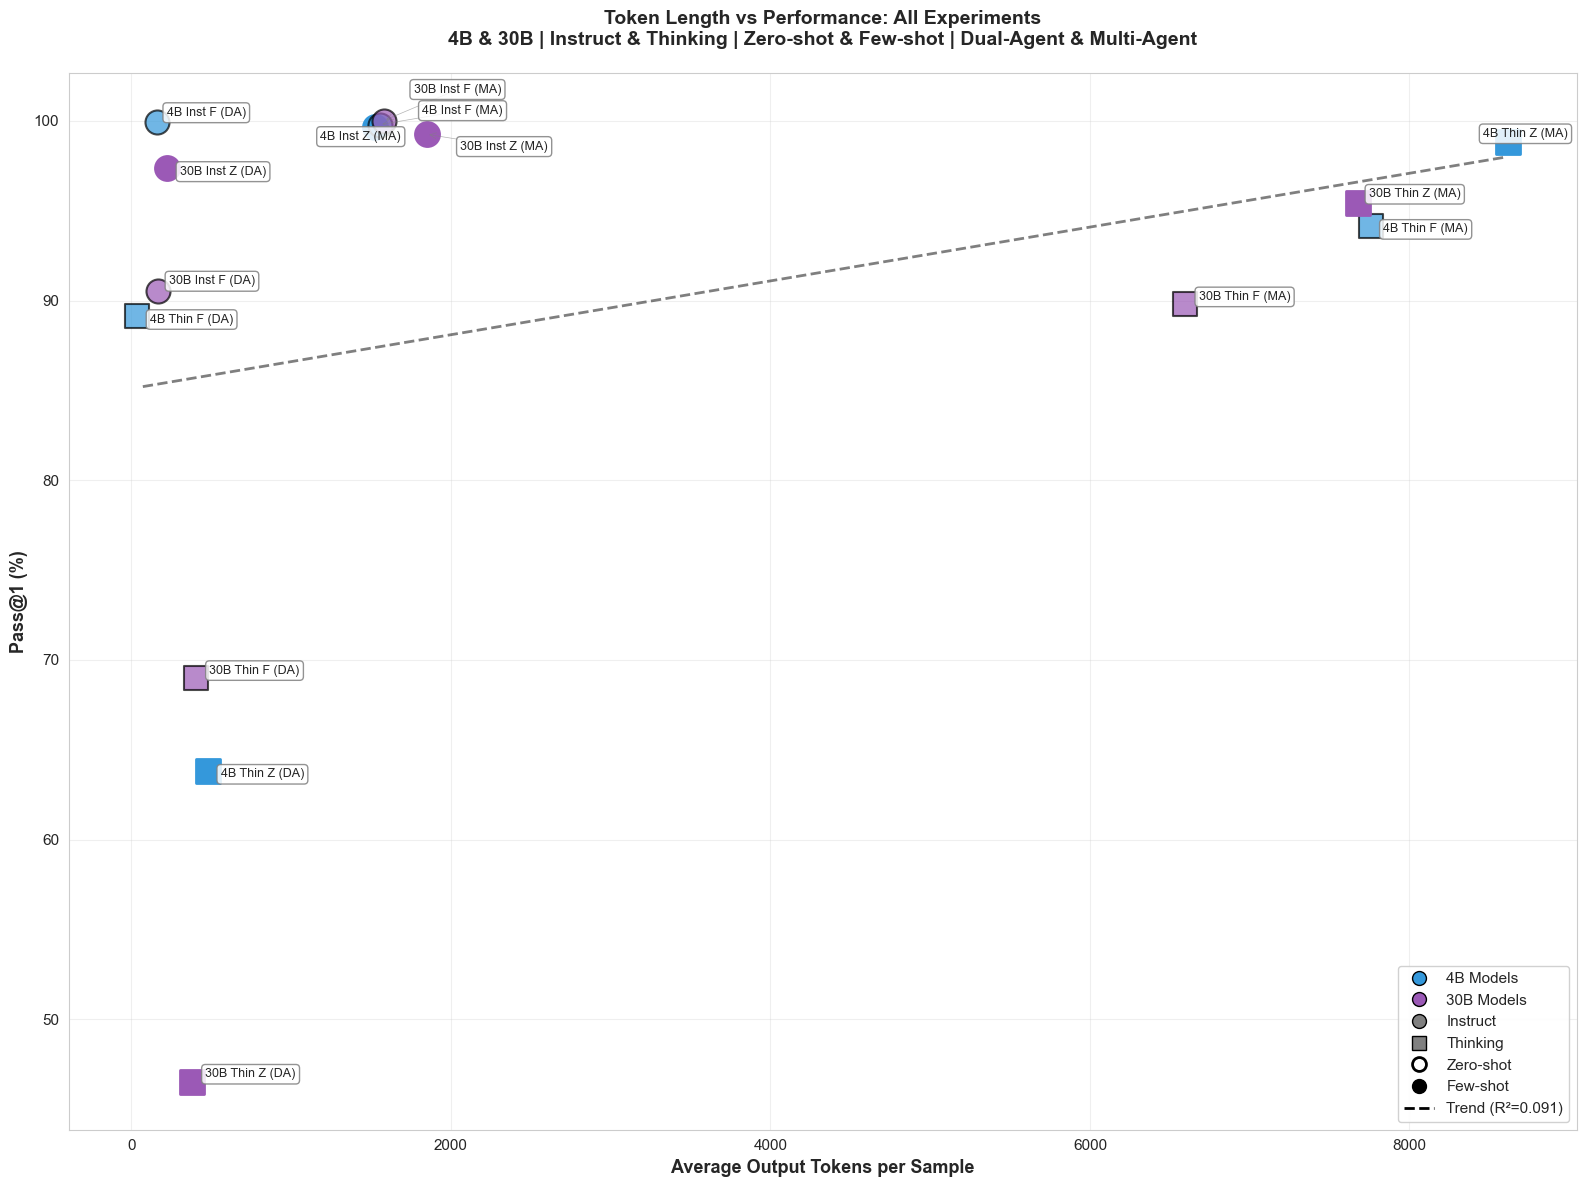


📊 Token Length vs Pass@1 Analysis:
   Correlation: r = 0.301, R² = 0.091
   Slope: 0.0015 (Pass@1% change per 1000 tokens: 1.50%)
   P-value: 0.2753 (not significant)


In [84]:
# Token Length vs Pass@1 Visualization (Styled like RQ1)
from scipy.stats import linregress
from matplotlib.lines import Line2D

# Ensure adjustText is available
try:
    from adjustText import adjust_text
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'adjustText', '-q'])
    from adjustText import adjust_text

# Remove duplicates and NaN values
df_plot = df_code.dropna(subset=['avg_output_tokens', 'pass_at_1_pct']).copy()

# Add small jitter to overlapping points
np.random.seed(42)
jitter_tokens = 50    # Small jitter in tokens
jitter_pass = 0.5     # Small jitter in Pass@1%

df_plot['tokens_jitter'] = df_plot['avg_output_tokens'] + np.random.uniform(-jitter_tokens, jitter_tokens, len(df_plot))
df_plot['pass_jitter'] = df_plot['pass_at_1_pct'] + np.random.uniform(-jitter_pass, jitter_pass, len(df_plot))

# Create figure
fig, ax = plt.subplots(figsize=(16, 12))

# Define colors and markers
colors_map = {'4B': '#3498DB', '30B': '#9B59B6'}  # Blue for 4B, Purple for 30B
base_markers_map = {'Instruct': 'o', 'Thinking': 's'}  # Circle for Instruct, Square for Thinking

# Store annotation texts
texts = []

# Plot each configuration
for _, row in df_plot.iterrows():
    color = colors_map[row['model_size']]
    base_marker = base_markers_map[row['model_type']]
    
    # Use hollow markers for Zero-shot, filled for Few-shot
    if row['prompting'] == 'Zero-shot':
        facecolor = 'none'
        edgecolor = color
        linewidth = 2
    else:  # Few-shot
        facecolor = color
        edgecolor = 'black'
        linewidth = 1.5
    
    # Create label with agent type
    prompting_abbr = 'Z' if row['prompting'] == 'Zero-shot' else 'F'
    size_abbr = row['model_size']
    type_abbr = row['model_type'][:4]
    agent_abbr = 'DA' if row['agent_type'] == 'Dual-Agent' else 'MA'
    
    # Format: "4B Inst Z (DA)" or "30B Thin F (MA)"
    label = f"{size_abbr} {type_abbr} {prompting_abbr} ({agent_abbr})"
    
    # Plot point with jitter
    ax.scatter(
        row['tokens_jitter'],
        row['pass_jitter'],
        s=300,
        c=facecolor if facecolor != 'none' else edgecolor,
        marker=base_marker,
        edgecolors=edgecolor,
        linewidths=linewidth,
        alpha=0.7 if facecolor != 'none' else 1.0,
        facecolors=facecolor,
        zorder=3
    )
    
    # Add label to list
    text = ax.annotate(
        label,
        (row['tokens_jitter'], row['pass_jitter']),
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.85),
        zorder=4
    )
    texts.append(text)

# Adjust text positions to avoid overlap
adjust_text(texts,
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.6),
            ax=ax,
            expand_points=(1.5, 1.5),
            force_points=(0.5, 0.5),
            force_text=(0.5, 0.5))

# Calculate and plot trend line (using original values, not jittered)
slope, intercept, r_value, p_value, std_err = linregress(
    df_plot['avg_output_tokens'], 
    df_plot['pass_at_1_pct']
)
x_trend = np.array([df_plot['avg_output_tokens'].min(), df_plot['avg_output_tokens'].max()])
y_trend = slope * x_trend + intercept
ax.plot(x_trend, y_trend, 'k--', linewidth=2, alpha=0.5, zorder=1, label=f'Trend (R²={r_value**2:.3f})')

# Customize plot
ax.set_xlabel('Average Output Tokens per Sample', fontsize=13, fontweight='bold')
ax.set_ylabel('Pass@1 (%)', fontsize=13, fontweight='bold')
ax.set_title('Token Length vs Performance: All Experiments\n4B & 30B | Instruct & Thinking | Zero-shot & Few-shot | Dual-Agent & Multi-Agent',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, zorder=0)

# Create custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498DB', markersize=10, 
           markeredgecolor='black', label='4B Models', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9B59B6', markersize=10, 
           markeredgecolor='black', label='30B Models', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='Instruct', linewidth=0),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='Thinking', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=10, 
           markeredgecolor='black', markeredgewidth=2, label='Zero-shot', linewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, 
           markeredgecolor='black', label='Few-shot', linewidth=0),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label=f'Trend (R²={r_value**2:.3f})')
]
ax.legend(handles=legend_elements, loc='best', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_code_token_length_vs_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Token Length vs Pass@1 Analysis:")
print(f"   Correlation: r = {r_value:.3f}, R² = {r_value**2:.3f}")
print(f"   Slope: {slope:.4f} (Pass@1% change per 1000 tokens: {slope*1000:.2f}%)")
print(f"   P-value: {p_value:.4f} {'(significant)' if p_value < 0.05 else '(not significant)'}")

## 8. Comprehensive Heatmap

📊 Pass@1 Heatmap (Configuration × Agent Type):

agent_type              Dual-Agent  Multi-Agent
config                                         
30B-Instruct-Few-shot        90.85       100.00
30B-Instruct-Zero-shot       97.56        99.39
30B-Thinking-Few-shot        68.90        90.24
30B-Thinking-Zero-shot       46.58        95.12
4B-Instruct-Few-shot        100.00       100.00
4B-Instruct-Zero-shot          NaN       100.00
4B-Thinking-Few-shot         89.02        94.51
4B-Thinking-Zero-shot        64.02        98.78


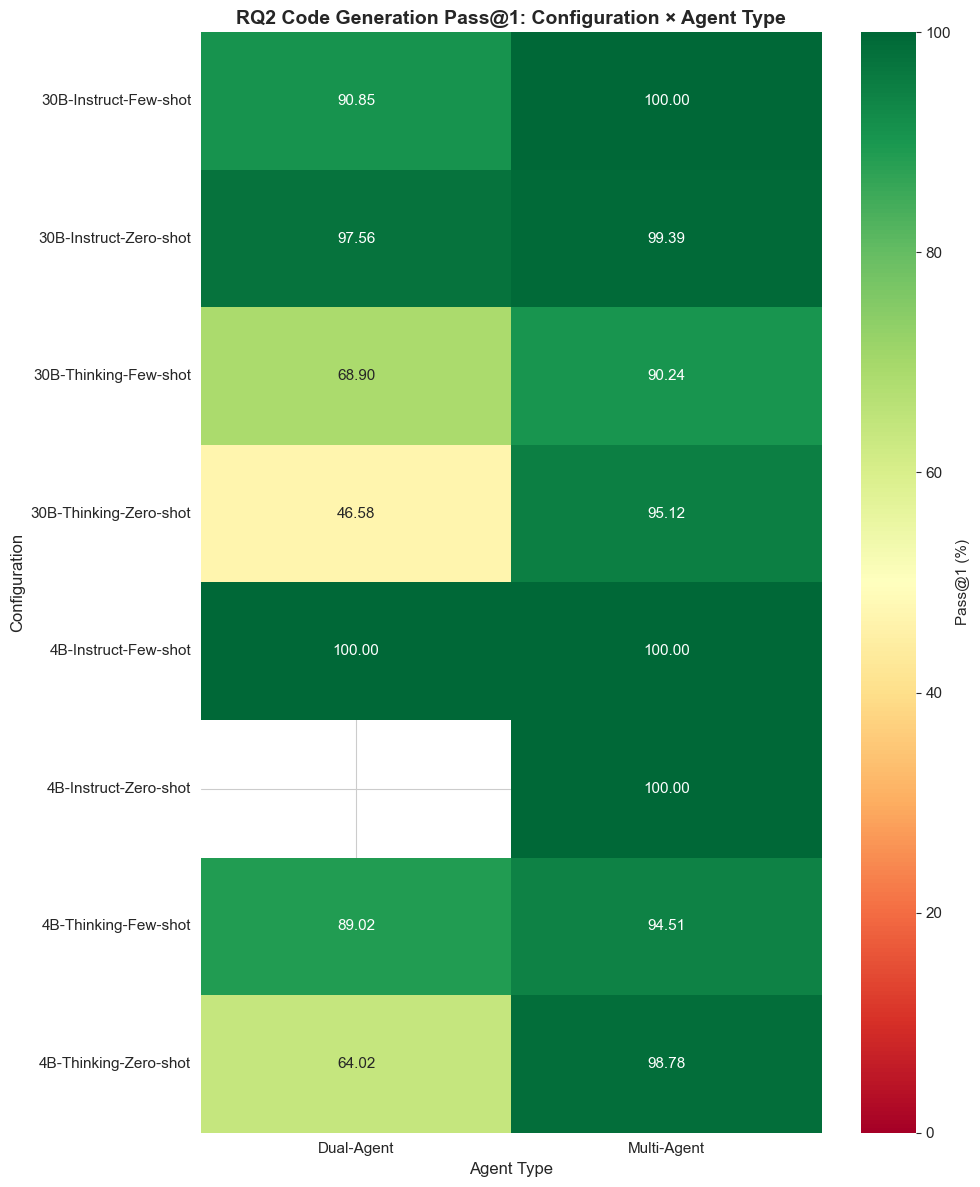

In [85]:
# Create configuration column
df_code['config'] = df_code['model_size'] + '-' + df_code['model_type'] + '-' + df_code['prompting']

# Pivot table for heatmap
heatmap_data = df_code.pivot_table(
    values='pass_at_1_pct',
    index='config',
    columns='agent_type',
    aggfunc='mean'
)

print("📊 Pass@1 Heatmap (Configuration × Agent Type):\n")
print(heatmap_data.round(2))

# Visualization
plt.figure(figsize=(10, 12))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=100, cbar_kws={'label': 'Pass@1 (%)'})
plt.title('RQ2 Code Generation Pass@1: Configuration × Agent Type',
          fontsize=14, fontweight='bold')
plt.xlabel('Agent Type', fontsize=12)
plt.ylabel('Configuration', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq2_code_configuration_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Summary & Export

In [86]:
# Export to Excel
excel_file = OUTPUT_DIR / 'rq2_code_generation_analysis.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_code.to_excel(writer, sheet_name='All Results', index=False)
    agent_comparison.to_excel(writer, sheet_name='DA vs MA')
    prompting_comparison.to_excel(writer, sheet_name='Prompting Strategy')
    size_comparison.to_excel(writer, sheet_name='Model Size')
    type_comparison.to_excel(writer, sheet_name='Model Type')

print(f"\n✅ Analysis complete!")
print(f"📊 Excel file saved: {excel_file}")
print(f"🖼️  Visualizations saved to: {OUTPUT_DIR}/")

# Display final summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"\nTotal Experiments Analyzed: {len(df_code)}")
print(f"\nBest Pass@1: {df_code['pass_at_1_pct'].max():.2f}% ({df_code.loc[df_code['pass_at_1_pct'].idxmax(), 'config']})")
print(f"\nAverage Pass@1 by Agent Type:")
print(f"  - Dual-Agent: {df_code[df_code['agent_type'] == 'Dual-Agent']['pass_at_1_pct'].mean():.2f}%")
print(f"  - Multi-Agent: {df_code[df_code['agent_type'] == 'Multi-Agent']['pass_at_1_pct'].mean():.2f}%")
print(f"\nAverage Energy Consumption: {df_code['total_energy_kwh'].mean():.3f} kWh")
print(f"Average CO2 Emissions: {df_code['total_emissions_kg'].mean():.3f} kg")
print("\n" + "="*80)


✅ Analysis complete!
📊 Excel file saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis/rq2/rq2_code_generation_analysis.xlsx
🖼️  Visualizations saved to: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis/rq2/

FINAL SUMMARY

Total Experiments Analyzed: 15

Best Pass@1: 100.00% (4B-Instruct-Zero-shot)

Average Pass@1 by Agent Type:
  - Dual-Agent: 79.56%
  - Multi-Agent: 97.26%

Average Energy Consumption: 0.488 kWh
Average CO2 Emissions: 0.083 kg



## 10. Key Findings

**To be filled after analysis:**

### RQ2.1: Dual-Agent vs Multi-Agent
- Pass@1 difference: [TBD]
- Quality of generated code: [TBD]

### RQ2.2: Prompting Strategy
- Zero-shot vs Few-shot impact: [TBD]
- Best practices: [TBD]

### RQ2.3: Model Configuration
- Model size impact: [TBD]
- Reasoning capability impact: [TBD]

### RQ2.4: Energy Efficiency
- Cost-benefit analysis: [TBD]
- Optimal configuration: [TBD]